# Breakup Continuum Discretized Coupled Channels for $^{8}$B+$^{208}$Pb at 83 MeV/u

We will adapt [this example from the Frescox documentation](https://www.fresco.org.uk/examples/B3-example-br-long.in), which only models $s$-wave breakup. 

From the documentation:

> Breakup calculations can be modeled as single-particle excitation into the continuum. In this example we show a typical CDCC calculation. It calculates the breakup of 8B into p + 7Be, under the field of 208Pb at intermediate energies. [...] The breakup of 8B has been measured many  times with the aim of extracting the proton capture rate on 7Be

Note, that even when neglecting couplings with $l >0$, the CDCC caclulation will already take a minute or so to run! For production use, expensive calculations like this would be better performed using [{{bfrescoxpro}}](https://bfrescox.readthedocs.io/en/latest/advanced_users.html), which allows MPI and OpenMP parallelization.

In [1]:
import inspect
import json
import os
import shutil
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

with open("MatplotlibEsthetics.json", "r") as fptr:
    esthetics = json.load(fptr)

# plt.style.use(esthetics["style"])
FONTSIZE = esthetics["fontsize"]
TICK_FONTSIZE = esthetics["tick_fontsize"]
MARKERSIZE = esthetics["markersize"]
LINEWIDTH = esthetics["linewidth"]

## BfrescoxPro

CDCC calculations are expensive. In practice, one would want to enable MPI parallelization for this sort of calculation. [See the docs for how to do this.](https://bfrescox.readthedocs.io/en/latest/advanced_users.html).

In [2]:
import bfrescox

bfrescox.information()

{'supports_mpi': False,
 'supports_openmp': False,
 'supports_lapack': False,
 'supports_corex': False,
 'frescox_exe': PosixPath('/home/beyerk/Projects/Bfrescox/bfrescox_pypkg/src/bfrescox/bin/frescox')}

In [3]:
EXAMPLE_DIR = Path("./Breakup_template//")
TEMPLATE_FILE_PATH = Path(EXAMPLE_DIR / "B3-example-br-long.template")
INPUT_FILE_PATH = Path(EXAMPLE_DIR / "B3-example-br-long.in")

## Let's run the input file exactly as is from the website

In [4]:
with open(INPUT_FILE_PATH, "r") as temp:
    input_file = temp.read()

print("Frescox input file from https://www.fresco.org.uk/examples/B5-example-br.in:")
print("-----------------------------------")
print(input_file)

Frescox input file from https://www.fresco.org.uk/examples/B5-example-br.in:
-----------------------------------
CDCC 8B+208Pb ; nuclear and coulomb s-waves                                                    
NAMELIST
 &Fresco  hcm= 0.01 rmatch= -60.000 rintp=  0.15 rsp=   0.0
     rasym=  1000.00 accrcy= 0.0010000 
     jtmin=   0.0 jtmax=   9000.0 absend=  -50.0000 
      jump =       1      10      50     200     
      jbord=     0.0   200.0   300.0  1000.0  9000.0   
     thmin=  0.00 thmax=  20.00 thinc=  0.05  cutr=-20.00
     ips= 0.0000  it0= 0 iter=  0 iblock= 21 nnu= 24
     smallchan= 1.00E-12  smallcoup= 1.00E-12
     chans= 1 smats= 2 xstabl= 1 cdcc= 1
     elab=   656.0000    pel=1 exl=1 lab=1 lin=1 lex=1 /

 &Partition namep='8B      ' massp=  8.0000 zp=  5 nex= 21 pwf=T                
            namet='208Pb   ' masst=208.0000 zt= 82 qval=  0.1370/               
 &States jp= 1.5 ptyp=-1 ep=  0.0000  cpot=  1                                  
         jt= 0.0 ptyt= 1

In [5]:
# from the input file
# Frescox uses
energy_bins = np.array(
    [
        0.1583,
        0.2180,
        0.3260,
        0.4830,
        0.6889,
        0.9438,
        1.2478,
        1.6007,
        2.0027,
        2.4536,
        2.9536,
        3.5025,
        4.1005,
        4.7474,
        5.4434,
        6.1884,
        6.9824,
        7.8253,
        8.7173,
        9.6583,
    ]
)

In [6]:
# Create the frescox input file by filling in the user-defined template with parameters
cfg = bfrescox.Configuration.from_template(
    INPUT_FILE_PATH,
    EXAMPLE_DIR.joinpath("frescox.in"),
    {},
    overwrite=True,
)

In [7]:
%%time
bfrescox.run_simulation(
    cfg, EXAMPLE_DIR.joinpath("frescox.out"), cwd=EXAMPLE_DIR, overwrite=True
)

CPU times: user 5.03 ms, sys: 997 μs, total: 6.03 ms
Wall time: 1min 55s


In [8]:
results = bfrescox.parse_fort16(EXAMPLE_DIR.joinpath("fort.16"))
results.keys()

dict_keys(['channel_1', 'channel_2', 'channel_3', 'channel_4', 'channel_5', 'channel_6', 'channel_7', 'channel_8', 'channel_9', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_20', 'channel_21'])

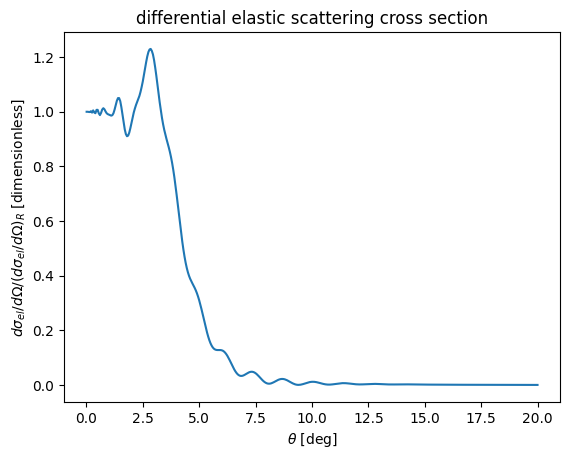

In [9]:
fig, ax = plt.subplots()

plt.plot(results["channel_1"]["Theta_deg"], results["channel_1"]["sigma_mb_sr"])

ax.set_xlabel(r"$\theta$ [deg]")
ax.set_ylabel(r"$d\sigma_{el}/d\Omega / (d\sigma_{el}/d\Omega)_R$ [dimensionless]")
ax.set_title(r"differential elastic scattering cross section")
plt.show()

In [10]:
# get breakup channels (elastic is always channel 1)
br_channels = dict([(k, results[k]) for k in results.keys() if k != "channel_1"])

In [11]:
dsigma_dOmega = np.zeros((len(br_channels), len(results["channel_1"]["Theta_deg"])))
for i, key in enumerate(br_channels):
    theta = np.array(np.deg2rad(results[key]["Theta_deg"]))
    dsigma_dOmega[i, :] = results[key]["sigma_mb_sr"]

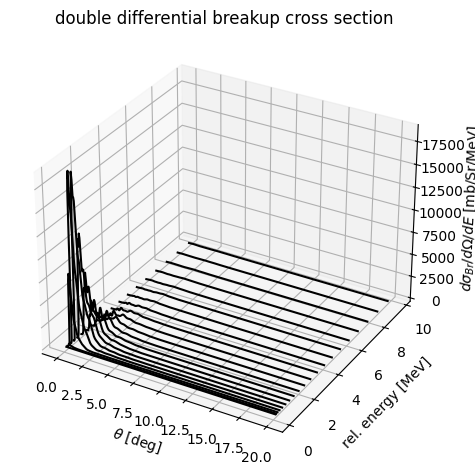

In [12]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d")

for i in range(dsigma_dOmega.shape[0]):
    x = np.rad2deg(theta)
    y = np.ones_like(x) * energy_bins[i]
    z = dsigma_dOmega[i, :]
    ax.plot(x, y, z, color="k")

# sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label("E [MeV]")

ax.set_ylabel(r"rel. energy [MeV]")
ax.set_xlabel(r"$\theta$ [deg]")
ax.set_zlabel(r"$d\sigma_{Br}/d\Omega / dE$ [mb/Sr/MeV]")
# ax.set_zscale("log")
ax.set_title("double differential breakup cross section")
plt.tight_layout()
plt.show()

Integrating over solid angle, we get the differential breakup cross section with respect to energy:

In [13]:
x = theta[None, :]
dsigma_br_dE = (
    2
    * np.pi
    * np.trapezoid(dsigma_dOmega * np.sin(x), x, axis=1)[1:]
    / np.diff(energy_bins)
)

(0.0, 10.0)

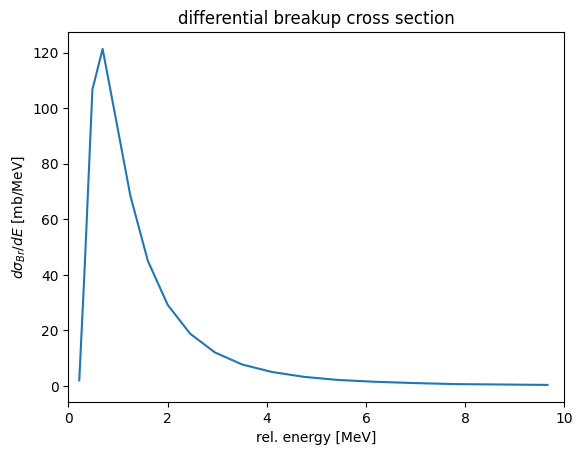

In [14]:
fig, ax = plt.subplots()
ax.set_xlabel(r"rel. energy [MeV]")
ax.set_ylabel(r"$d\sigma_{Br}/dE$ [mb/MeV]")
ax.set_title("differential breakup cross section")

ax.plot(energy_bins[1:], dsigma_br_dE)
ax.set_xlim([0, 10])

Integrating over all energies, we get the breakup differential cross section with respect to angle:

In [15]:
dsigma_br_dOmega_b_per_Sr = np.sum(dsigma_dOmega, axis=0) / 1000

(0.0, 5.0)

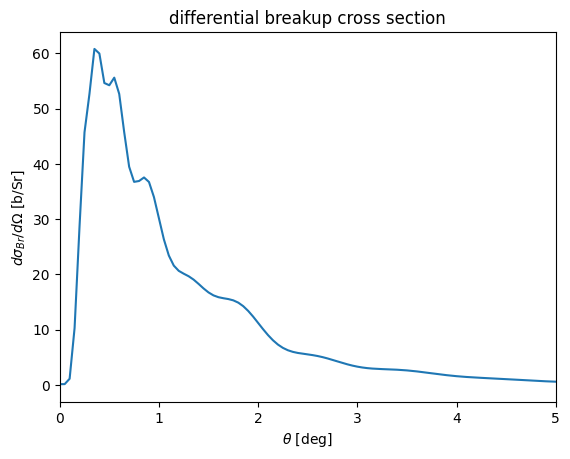

In [16]:
fig, ax = plt.subplots()
ax.set_xlabel(r"$\theta$ [deg]")
ax.set_ylabel(r"$d\sigma_{Br}/d\Omega$ [b/Sr]")
ax.set_title("differential breakup cross section")

ax.plot(np.rad2deg(theta), dsigma_br_dOmega_b_per_Sr)
ax.set_xlim([0, 5])

## Using the template for breakup

The template is the same as the input file, but we've replace the parameters

In [17]:
with open(TEMPLATE_FILE_PATH, "r") as temp:
    template_file = temp.read()

print("-----------------------------------")
print(template_file)

-----------------------------------
CDCC 8B+208Pb ; nuclear and coulomb s-waves                                                    
NAMELIST
 &Fresco  hcm= 0.01 rmatch= -60.000 rintp=  0.15 rsp=   0.0
     rasym=  1000.00 accrcy= 0.0010000 
     jtmin=   0.0 jtmax=   9000.0 absend=  -50.0000 
      jump =       1      10      50     200     
      jbord=     0.0   200.0   300.0  1000.0  9000.0   
     thmin=  0.00 thmax=  20.00 thinc=  0.05  cutr=-20.00
     ips= 0.0000  it0= 0 iter=  0 iblock= 21 nnu= 24
     smallchan= 1.00E-12  smallcoup= 1.00E-12
     chans= 1 smats= 2 xstabl= 1 cdcc= 1
     elab=   656.0000    pel=1 exl=1 lab=1 lin=1 lex=1 /

 &Partition namep='8B      ' massp=  8.0000 zp=  5 nex= 21 pwf=T                
            namet='208Pb   ' masst=208.0000 zt= 82 qval=  0.1370/               
 &States jp= 1.5 ptyp=-1 ep=  0.0000  cpot=  1                                  
         jt= 0.0 ptyt= 1 et=  0.0000/                                           
 &States jp= 0.5 pty

Because we have a few different interactions, it is nice to break up the parameters:

In [18]:
params_by_interaction = {
    "8B_208Pb": {
        "rC": 2.65,
    },
    "7Be_208Pb": {
        "rC": 1.3,
        "V": 114.2,
        "rV": 1.286,
        "aV": 0.853,
        "W": 9.44,
        "rW": 1.739,
        "aW": 0.809,
    },
    "p_208Pb": {
        "rC": 1.3,
        "V": 34.819,
        "rV": 1.17,
        "aV": 0.75,
        "W": 15.430,
        "rW": 1.32,
        "aW": 0.601,
    },
    "p_7Be": {
        "rC": 2.391,
        "V": 44.675,
        "rV": 2.391,
        "aV": 0.48,
        "Vso": 4.898,
        "rso": 2.391,
        "aso": 0.48,
    },
}

And we can write some handy functions to flatten parameter dicts in this form into the form expected by {{bfrescox}}, and vice versa:

In [19]:
def make_all_params(params_by_interaction: dict) -> dict:
    all_params = {}
    for suffix, param_set in params_by_interaction.items():
        for key, val in param_set.items():
            new_key = f"{key}_{suffix}"
            assert "@" not in key and "@" not in suffix
            assert new_key not in all_params
            all_params[new_key] = val
    return all_params


def make_params_by_interaction(all_params: dict) -> dict:
    params_by_interaction = {}
    for key, val in all_params.items():
        split_key = key.split("_")
        new_key = split_key[0]
        suffix = key[len(new_key) + 1 :]
        if suffix not in params_by_interaction:
            params_by_interaction[suffix] = {new_key: val}
        else:
            assert new_key not in params_by_interaction[suffix]
            params_by_interaction[suffix][new_key] = val
    return params_by_interaction

In [20]:
assert params_by_interaction == make_params_by_interaction(
    make_all_params(params_by_interaction)
)

The form expected by {{bfrescox}}, with parameter names corresponding to our template:

In [21]:
make_all_params(params_by_interaction)

{'rC_8B_208Pb': 2.65,
 'rC_7Be_208Pb': 1.3,
 'V_7Be_208Pb': 114.2,
 'rV_7Be_208Pb': 1.286,
 'aV_7Be_208Pb': 0.853,
 'W_7Be_208Pb': 9.44,
 'rW_7Be_208Pb': 1.739,
 'aW_7Be_208Pb': 0.809,
 'rC_p_208Pb': 1.3,
 'V_p_208Pb': 34.819,
 'rV_p_208Pb': 1.17,
 'aV_p_208Pb': 0.75,
 'W_p_208Pb': 15.43,
 'rW_p_208Pb': 1.32,
 'aW_p_208Pb': 0.601,
 'rC_p_7Be': 2.391,
 'V_p_7Be': 44.675,
 'rV_p_7Be': 2.391,
 'aV_p_7Be': 0.48,
 'Vso_p_7Be': 4.898,
 'rso_p_7Be': 2.391,
 'aso_p_7Be': 0.48}

### Test the effect of individual parameters on the breakup cross sections

This will take some time to run!

In [22]:
params_to_perturb = {
    "p_7Be": {
        "rV": [1.3,1.9,2.5,3.1],
    }
}

In [23]:
def post_process(result):
    theta_deg, elastic_ratio_rutherford = (
        result["channel_1"]["Theta_deg"],
        result["channel_1"]["sigma_mb_sr"],
    )
    br_channels = dict([(k, result[k]) for k in result.keys() if k != "channel_1"])
    dsigma_dOmega = np.zeros((len(br_channels), len(results["channel_1"]["Theta_deg"])))
    for i, key in enumerate(br_channels):
        theta = np.array(np.deg2rad(result[key]["Theta_deg"]))
        dsigma_dOmega[i, :] = result[key]["sigma_mb_sr"]

    # angle integrated
    x = theta[None, :]
    dsigma_br_dE_mb_per_MeV = (
        2
        * np.pi
        * np.trapezoid(dsigma_dOmega * np.sin(x), x, axis=1)[1:]
        / np.diff(energy_bins)
    )
    # energy integrated
    dsigma_br_dOmega_mb_per_Sr = np.sum(dsigma_dOmega, axis=0)
    return {
        "theta_deg" : theta_deg,
        "elastic_ratio_rutherford": elastic_ratio_rutherford,
        "dsigma_br_dE_mb_per_MeV": dsigma_br_dE_mb_per_MeV,
        "dsigma_br_dOmega_mb_per_Sr" : dsigma_br_dOmega_mb_per_Sr,
    }

In [24]:
%%time
perturbed_results = {}
for interaction, perturb_list in params_to_perturb.items():
    perturbed_results[interaction] = {}
    for key, vals in perturb_list.items():
        perturbed_results[interaction][key] = []
        for val in vals:

            params = params_by_interaction.copy()
            params[interaction][key] = val
            cfg = bfrescox.Configuration.from_template(
                TEMPLATE_FILE_PATH,
                EXAMPLE_DIR.joinpath("frescox.in"),
                make_all_params(params),
                overwrite=True,
            )
            bfrescox.run_simulation(
                cfg,
                EXAMPLE_DIR.joinpath("frescox.out"),
                cwd=EXAMPLE_DIR,
                overwrite=True,
            )
            perturbed_results[interaction][key].append(
                post_process(
                    bfrescox.parse_fort16(EXAMPLE_DIR.joinpath("fort.16"))
                )
            )

CPU times: user 86.5 ms, sys: 3.87 ms, total: 90.4 ms
Wall time: 7min 40s


## Plot parameter sensitivities for breakup and elastic observables

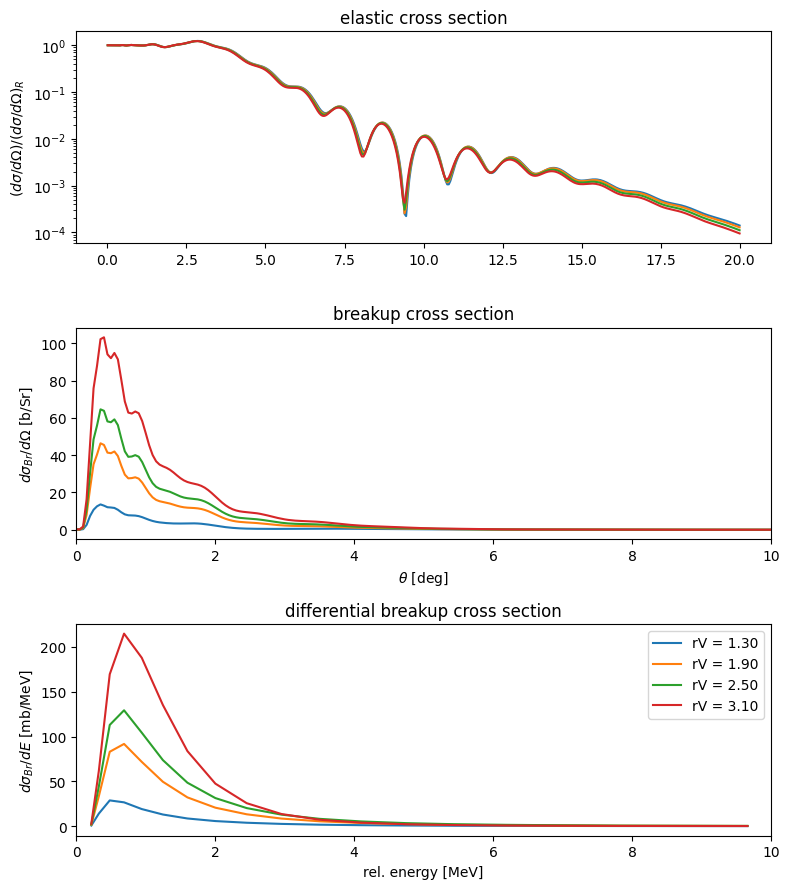

In [25]:
for interaction, perturb_list in params_to_perturb.items():
    for key, vals in perturb_list.items():
        fig, axes = plt.subplots(3, 1,  figsize=(8, 9))
        for i in range(len(vals)):
            result = perturbed_results[interaction][key][i]
            
            axes[0].semilogy(result["theta_deg"], result["elastic_ratio_rutherford"], label=f"{key} = {vals[i]:1.2f}")
            axes[0].set_ylabel(r"$(d\sigma/d\Omega)/(d\sigma/d\Omega)_R$")
            axes[0].set_title("elastic cross section")
            axes[1].set_xlabel(r"$\theta$ [deg]")

            axes[1].plot(result["theta_deg"], result["dsigma_br_dOmega_mb_per_Sr"]/1000, label=f"{key} = {vals[i]:1.2f}")
            axes[1].set_ylabel(r"$d\sigma_{Br}/d\Omega$ [b/Sr]")
            axes[1].set_title("breakup cross section")
            axes[1].set_xlabel(r"$\theta$ [deg]")
            axes[1].set_xlim([0,10])

            axes[2].set_xlabel(r"rel. energy [MeV]")
            axes[2].set_ylabel(r"$d\sigma_{Br}/dE$ [mb/MeV]")
            axes[2].set_title("differential breakup cross section")
            
            axes[2].plot(energy_bins[1:], result["dsigma_br_dE_mb_per_MeV"], label=f"{key} = {vals[i]:1.2f}")
            axes[2].set_xlim([0, 10])
            axes[2].legend()
        plt.tight_layout()
        plt.show()